# 🏥 Sepsis Survival Prediction
### Binary Classification with Logistic Regression · XGBoost · TabNet

---

## Problem Statement

**Dataset:** Nachimuthu & Vishwanathan (2020), *Scientific Reports* — DOI: `10.1038/s41598-020-73558-3`  
**Task:** Predict in-hospital mortality for sepsis patients (binary: survived vs. died)  
**Target:** `hospital_outcome_1alive_0dead` → 1 = survived, 0 = died  

**Cohorts:**
| Cohort | Rows | Mortality Rate |
|--------|------|----------------|
| Primary | 110,204 | ~7.4% |
| Study | 19,051 | ~18.9% |
| Validation | 137 | ~17.5% |

**Key challenge:** Severe class imbalance. In clinical settings, **recall for the minority class (deaths)** is the most critical metric — missing a death is far more costly than a false alarm.

---
### Why TabPFN is NOT used
> TabPFN (Hollmann et al., 2022) is a prior-data-fitted transformer designed for **≤1,000 samples and ≤100 features**. Our modelling pool exceeds 129,000 rows — roughly 130× beyond its design limit. Using it would require batching that violates its in-context learning assumptions and eliminates its speed advantage. **TabNet** is the appropriate deep learning alternative at this scale.

---
## 1. Setup & Imports

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
!pip install pytorch-tabnet xgboost imbalanced-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00


In [2]:
import warnings, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# XGBoost
import xgboost as xgb

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

TARGET   = 'hospital_outcome_1alive_0dead'
FEATURES = ['age_years', 'sex_0male_1female', 'episode_number']

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

print(f'PyTorch  : {torch.__version__}')
print(f'XGBoost  : {xgb.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

PyTorch  : 2.10.0+cpu
XGBoost  : 3.2.0
CUDA     : False


---
## 2. Data Loading

In [3]:
# ── File paths — adjust if running locally ────────────────────────────────────
PATH_PRIMARY    = 's41598-020-73558-3_sepsis_survival_primary_cohort.csv'
PATH_STUDY      = 's41598-020-73558-3_sepsis_survival_study_cohort.csv'
PATH_VALIDATION = 's41598-020-73558-3_sepsis_survival_validation_cohort.csv'

df_primary    = pd.read_csv(PATH_PRIMARY)
df_study      = pd.read_csv(PATH_STUDY)
df_validation = pd.read_csv(PATH_VALIDATION)

print(f'Primary cohort    : {df_primary.shape[0]:>7,} rows × {df_primary.shape[1]} cols')
print(f'Study cohort      : {df_study.shape[0]:>7,} rows × {df_study.shape[1]} cols')
print(f'Validation cohort : {df_validation.shape[0]:>7,} rows × {df_validation.shape[1]} cols')

df_primary.head(3)

Primary cohort    : 110,204 rows × 4 cols
Study cohort      :  19,051 rows × 4 cols
Validation cohort :     137 rows × 4 cols


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
0,21,1,1,1
1,20,1,1,1
2,21,1,1,1


---
## 3. Data Audit

### 3.1 Shape · Columns · Dtypes

In [4]:
def audit(df, name):
    print(f'\n{'─'*55}')
    print(f'  COHORT: {name.upper():<15}  ({df.shape[0]:,} rows)')
    print(f'{'─'*55}')
    print(df.dtypes.rename('dtype').to_frame().to_string())
    print('\nDescriptive Statistics:')
    display(df.describe().round(2))

for df, name in [(df_primary,'primary'),(df_study,'study'),(df_validation,'validation')]:
    audit(df, name)


───────────────────────────────────────────────────────
  COHORT: PRIMARY          (110,204 rows)
───────────────────────────────────────────────────────
                               dtype
age_years                      int64
sex_0male_1female              int64
episode_number                 int64
hospital_outcome_1alive_0dead  int64

Descriptive Statistics:


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
count,110204.00,110204.00,110204.00,110204.00
mean,62.74,0.47,1.35,0.93
std,24.13,0.50,0.75,0.26
min,0.00,0.00,1.00,0.00
25%,51.00,0.00,1.00,1.00
50%,68.00,0.00,1.00,1.00
75%,81.00,1.00,1.00,1.00
max,100.00,1.00,5.00,1.00



───────────────────────────────────────────────────────
  COHORT: STUDY            (19,051 rows)
───────────────────────────────────────────────────────
                               dtype
age_years                      int64
sex_0male_1female              int64
episode_number                 int64
hospital_outcome_1alive_0dead  int64

Descriptive Statistics:


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
count,19051.00,19051.00,19051.00,19051.00
mean,72.50,0.45,1.40,0.81
std,18.61,0.50,0.78,0.39
min,0.00,0.00,1.00,0.00
25%,65.00,0.00,1.00,1.00
50%,77.00,0.00,1.00,1.00
75%,85.00,1.00,2.00,1.00
max,100.00,1.00,5.00,1.00



───────────────────────────────────────────────────────
  COHORT: VALIDATION       (137 rows)
───────────────────────────────────────────────────────
                               dtype
age_years                      int64
sex_0male_1female              int64
episode_number                 int64
hospital_outcome_1alive_0dead  int64

Descriptive Statistics:


,age_years,sex_0male_1female,episode_number,hospital_outcome_1alive_0dead
count,137.00,137.00,137.00,137.00
mean,59.54,0.34,1.16,0.82
std,15.75,0.48,0.37,0.38
min,20.00,0.00,1.00,0.00
25%,50.00,0.00,1.00,1.00
50%,60.00,0.00,1.00,1.00
75%,72.00,1.00,1.00,1.00
max,89.00,1.00,2.00,1.00


### 3.2 Missing Values (%)

In [5]:
def missing_pct(df, name):
    miss = df.isnull().mean().mul(100).round(2).rename('missing_%')
    print(f'\n{name}:')
    print(miss.to_string())

for df, name in [(df_primary,'primary'),(df_study,'study'),(df_validation,'validation')]:
    missing_pct(df, name)

print('\n→ All cohorts: 0% missing values across all columns.')
print('→ No imputation required. Dataset is complete.')


primary:
age_years                        0.0
sex_0male_1female                0.0
episode_number                   0.0
hospital_outcome_1alive_0dead    0.0

study:
age_years                        0.0
sex_0male_1female                0.0
episode_number                   0.0
hospital_outcome_1alive_0dead    0.0

validation:
age_years                        0.0
sex_0male_1female                0.0
episode_number                   0.0
hospital_outcome_1alive_0dead    0.0

→ All cohorts: 0% missing values across all columns.
→ No imputation required. Dataset is complete.


### 3.3 Class Distribution

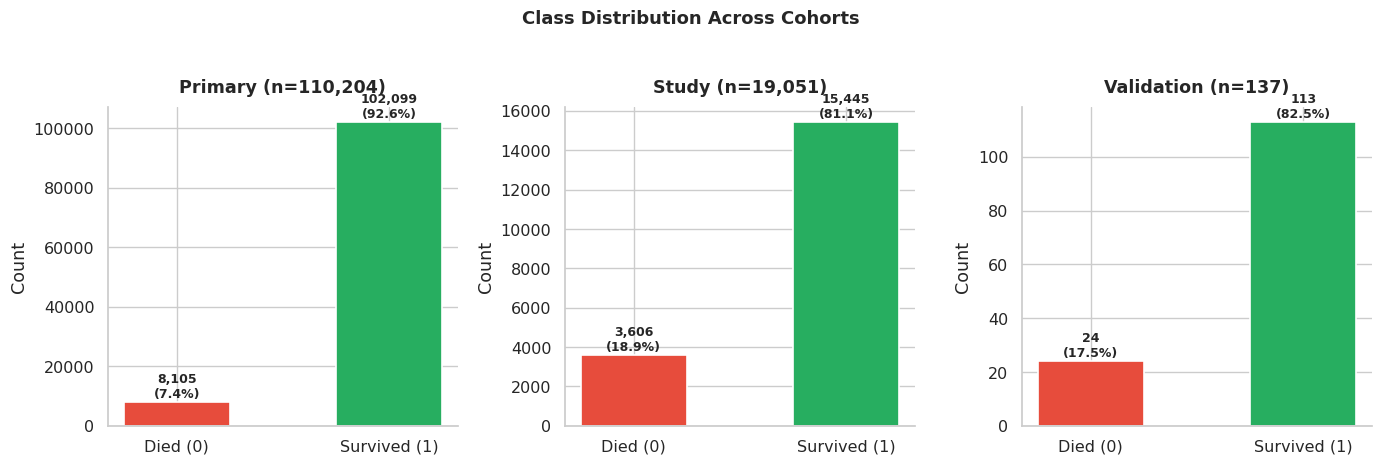


Imbalance ratios (survived:died):
  primary     : 12.6:1  |  mortality = 7.4%
  study       : 4.3:1  |  mortality = 18.9%
  validation  : 4.7:1  |  mortality = 17.5%


In [6]:
cohorts_meta = [
    (df_primary,    'Primary (n=110,204)'),
    (df_study,      'Study (n=19,051)'),
    (df_validation, 'Validation (n=137)'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (df, title) in zip(axes, cohorts_meta):
    vc = df[TARGET].value_counts().sort_index()
    colors_bar = ['#e74c3c', '#27ae60']
    bars = ax.bar(['Died (0)', 'Survived (1)'], vc.values,
                  color=colors_bar, edgecolor='white', linewidth=1.2, width=0.5)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel('Count')
    ax.spines[['top','right']].set_visible(False)
    for bar, cnt in zip(bars, vc.values):
        pct = cnt / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + len(df)*0.005,
                f'{cnt:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Class Distribution Across Cohorts', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

print('\nImbalance ratios (survived:died):')
for df, name in [(df_primary,'primary'),(df_study,'study'),(df_validation,'validation')]:
    pos = (df[TARGET]==1).sum()
    neg = (df[TARGET]==0).sum()
    print(f'  {name:<12}: {pos/neg:.1f}:1  |  mortality = {neg/len(df)*100:.1f}%')

**Observations:**
- Primary cohort mortality: ~7.4% — most patients survive
- Study cohort mortality: ~18.9% — higher-acuity population  
- Validation cohort (n=137) is the unseen test set — never touched during training
- Class imbalance demands explicit handling; **recall on class 0 (deaths) is the clinical priority**

---
## 4. Preprocessing

### 4.1 Imputation
No missing values found → no imputation needed. Code below is provided for completeness.

In [7]:
from sklearn.impute import SimpleImputer

# Numerical imputer — not triggered here (0% missing) but wired in for robustness
num_imputer = SimpleImputer(strategy='median')

# Categorical imputer — not triggered here (no categorical columns)
# cat_imputer = SimpleImputer(strategy='most_frequent')

print('All features: integer / numeric. No categorical encoding required.')
print('sex_0male_1female is already binary-encoded (0/1).')
print('\nFeatures used:', FEATURES)

All features: integer / numeric. No categorical encoding required.
sex_0male_1female is already binary-encoded (0/1).

Features used: ['age_years', 'sex_0male_1female', 'episode_number']


### 4.2 Scaling
- **Logistic Regression** → requires scaling (sensitive to feature magnitude)  
- **XGBoost** → tree-based, scale-invariant → **no scaling needed**  
- **TabNet** → internally applies batch normalisation, but pre-scaling to [0,1] or StandardScaler improves convergence stability → **scaling applied**

In [8]:
# Combine primary + study as the modelling pool
df_pool = pd.concat([df_primary, df_study], ignore_index=True)

X_pool = df_pool[FEATURES].values
y_pool = df_pool[TARGET].values

# Fixed held-out test set
X_test_raw = df_validation[FEATURES].values
y_test      = df_validation[TARGET].values

print(f'Modelling pool : {X_pool.shape[0]:,} rows')
print(f'Test set       : {X_test_raw.shape[0]} rows')

Modelling pool : 129,255 rows
Test set       : 137 rows


---
## 5. Train / Validation / Test Split

- **Stratified 80/20 split** on the modelling pool → preserves class ratios  
- Scaler is fit **only on X_train** — no leakage into val or test sets

In [9]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_pool, y_pool,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_pool
)

# Fit scaler on train only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc   = scaler.transform(X_val_raw)
X_test_sc  = scaler.transform(X_test_raw)

print(f'Train : {X_train_raw.shape[0]:>7,}  |  mortality {1-y_train.mean():.3f}')
print(f'Val   : {X_val_raw.shape[0]:>7,}  |  mortality {1-y_val.mean():.3f}')
print(f'Test  : {X_test_raw.shape[0]:>7,}  |  mortality {1-y_test.mean():.3f}')

Train : 103,404  |  mortality 0.091
Val   :  25,851  |  mortality 0.091
Test  :     137  |  mortality 0.175


---
## 6. Models

### Helper: Unified Evaluation

In [10]:
def get_metrics(name, y_true, y_prob, threshold=0.5):
    """Compute standard classification metrics dict."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':   name,
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC':  round(average_precision_score(y_true, y_prob), 4),
        'F1':      round(f1_score(y_true, y_pred), 4),
        'Recall':  round(recall_score(y_true, y_pred), 4),
    }

# Containers
val_results  = []
test_results = []
train_times  = {}
all_probs    = {}   # {name: y_prob} for curves

print('Evaluation helper ready.')

Evaluation helper ready.


### 6.1 Logistic Regression (Baseline)

Linear, fast, interpretable. `class_weight='balanced'` adjusts the loss for imbalance.

In [11]:
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)
train_times['Logistic Regression'] = round(time.time() - t0, 2)

lr_val_prob  = lr.predict_proba(X_val_sc)[:, 1]
lr_test_prob = lr.predict_proba(X_test_sc)[:, 1]

val_results.append(get_metrics('Logistic Regression', y_val, lr_val_prob))
test_results.append(get_metrics('Logistic Regression', y_test, lr_test_prob))
all_probs['Logistic Regression'] = lr_val_prob

print(f'Training time : {train_times["Logistic Regression"]}s')
print('Val metrics   :', val_results[-1])

Training time : 0.08s
Val metrics   : {'Model': 'Logistic Regression', 'ROC-AUC': np.float64(0.6917), 'PR-AUC': np.float64(0.9579), 'F1': 0.6993, 'Recall': 0.5528}


### 6.2 XGBoost (Primary Model)

Gradient-boosted trees. `scale_pos_weight = neg/pos` rescales the gradient for the minority class — cleaner than SMOTE at this scale and avoids synthetic noise.

In [12]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'scale_pos_weight = {spw:.3f}  (neg:{neg_count:,} / pos:{pos_count:,})')

t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators      = 400,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 1.0,
    scale_pos_weight  = spw,
    eval_metric       = 'aucpr',
    early_stopping_rounds = 30,
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbosity         = 0
)
xgb_model.fit(
    X_train_raw, y_train,
    eval_set          = [(X_val_raw, y_val)],
    verbose           = False
)
train_times['XGBoost'] = round(time.time() - t0, 2)

xgb_val_prob  = xgb_model.predict_proba(X_val_raw)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test_raw)[:, 1]

val_results.append(get_metrics('XGBoost', y_val, xgb_val_prob))
test_results.append(get_metrics('XGBoost', y_test, xgb_test_prob))
all_probs['XGBoost'] = xgb_val_prob

print(f'Training time     : {train_times["XGBoost"]}s')
print(f'Best iteration    : {xgb_model.best_iteration}')
print('Val metrics       :', val_results[-1])

scale_pos_weight = 0.100  (neg:9,369 / pos:94,035)
Training time     : 6.5s
Best iteration    : 128
Val metrics       : {'Model': 'XGBoost', 'ROC-AUC': np.float64(0.693), 'PR-AUC': np.float64(0.9583), 'F1': 0.6596, 'Recall': 0.5035}


### 6.3 TabNet (Deep Learning for Tabular Data)

TabNet (Arik & Pfister, 2021) uses sequential attention to select relevant features at each decision step — providing both performance and built-in interpretability.

**Architecture choices:**
- `N_d = N_a = 16` — narrow (only 3 features; wide networks overfit)
- `n_steps = 3` — minimal attention steps for a low-dimensional problem
- `momentum = 0.02` — small momentum for BatchNorm stability with imbalanced batches
- `weights = 1` — activates internal class-weight balancing

In [13]:
# Compute class weights for TabNet
classes     = np.array([0, 1])
class_wts   = compute_class_weight('balanced', classes=classes, y=y_train)
class_wt_dict = {0: class_wts[0], 1: class_wts[1]}
print(f'Class weights: {class_wt_dict}')

# TabNet expects float32 arrays
X_tr_tn  = X_train_sc.astype(np.float32)
X_vl_tn  = X_val_sc.astype(np.float32)
X_tst_tn = X_test_sc.astype(np.float32)
y_tr_tn  = y_train.astype(int)
y_vl_tn  = y_val.astype(int)

t0 = time.time()

tabnet = TabNetClassifier(
    n_d            = 16,
    n_a            = 16,
    n_steps        = 3,
    gamma          = 1.3,
    momentum       = 0.02,
    optimizer_fn   = torch.optim.Adam,
    optimizer_params = {'lr': 2e-3},
    scheduler_fn   = torch.optim.lr_scheduler.StepLR,
    scheduler_params = {'step_size': 10, 'gamma': 0.9},
    mask_type      = 'sparsemax',
    verbose        = 10,
    seed           = RANDOM_STATE,
    device_name    = 'cuda' if torch.cuda.is_available() else 'cpu'
)

tabnet.fit(
    X_tr_tn, y_tr_tn,
    eval_set          = [(X_vl_tn, y_vl_tn)],
    eval_name         = ['val'],
    eval_metric       = ['auc'],
    max_epochs        = 100,
    patience          = 15,
    batch_size        = 4096,
    virtual_batch_size= 512,
    weights           = 1,       # auto class-balancing
    drop_last         = False
)
train_times['TabNet'] = round(time.time() - t0, 2)

tn_val_prob  = tabnet.predict_proba(X_vl_tn)[:, 1]
tn_test_prob = tabnet.predict_proba(X_tst_tn)[:, 1]

val_results.append(get_metrics('TabNet', y_val, tn_val_prob))
test_results.append(get_metrics('TabNet', y_test, tn_test_prob))
all_probs['TabNet'] = tn_val_prob

print(f'\nTraining time : {train_times["TabNet"]}s')
print('Val metrics   :', val_results[-1])

Class weights: {0: np.float64(5.518411783541467), 1: np.float64(0.5498165576646993)}
epoch 0  | loss: 0.66298 | val_auc: 0.68481 |  0:00:08s
epoch 10 | loss: 0.62108 | val_auc: 0.69077 |  0:00:45s
epoch 20 | loss: 0.62096 | val_auc: 0.69267 |  0:01:20s

Early stopping occurred at epoch 22 with best_epoch = 7 and best_val_auc = 0.69303

Training time : 109.2s
Val metrics   : {'Model': 'TabNet', 'ROC-AUC': np.float64(0.693), 'PR-AUC': np.float64(0.9583), 'F1': 0.6754, 'Recall': 0.5223}


---
## 7. Evaluation

### 7.1 ROC & Precision-Recall Curves (Validation Set)

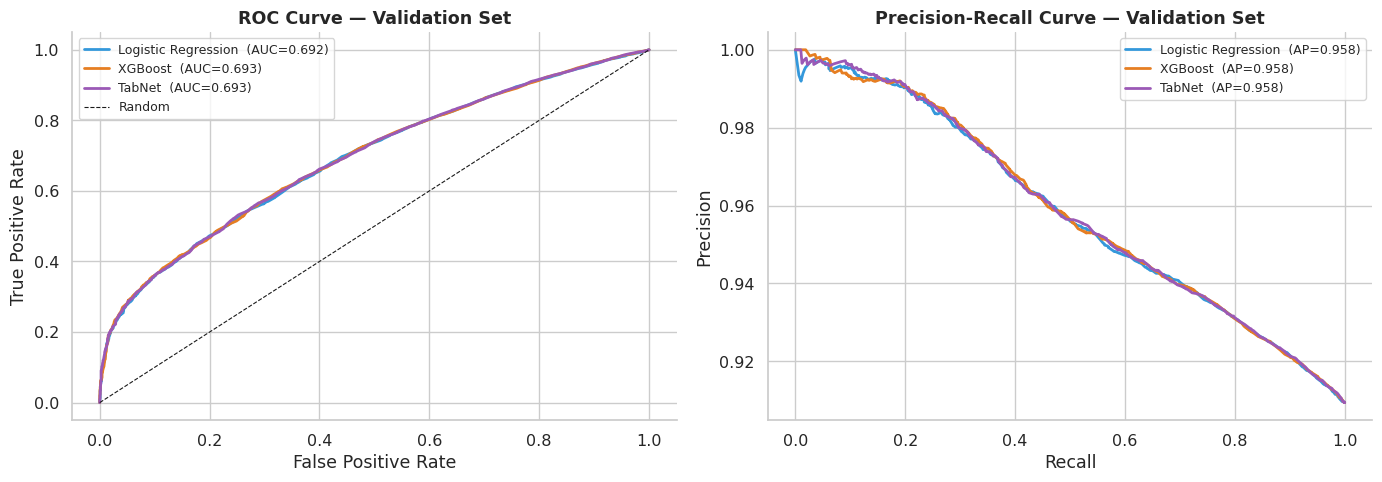

In [14]:
PALETTE = {
    'Logistic Regression': '#3498db',
    'XGBoost':             '#e67e22',
    'TabNet':              '#9b59b6'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for name, y_prob in all_probs.items():
    auc = roc_auc_score(y_val, y_prob)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name}  (AUC={auc:.3f})',
                 color=PALETTE[name], linewidth=2)
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# PR
from sklearn.metrics import precision_recall_curve
for name, y_prob in all_probs.items():
    prauc = average_precision_score(y_val, y_prob)
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    axes[1].plot(rec, prec, label=f'{name}  (AP={prauc:.3f})',
                 color=PALETTE[name], linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Validation Set', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()

### 7.2 Confusion Matrices (Validation Set)

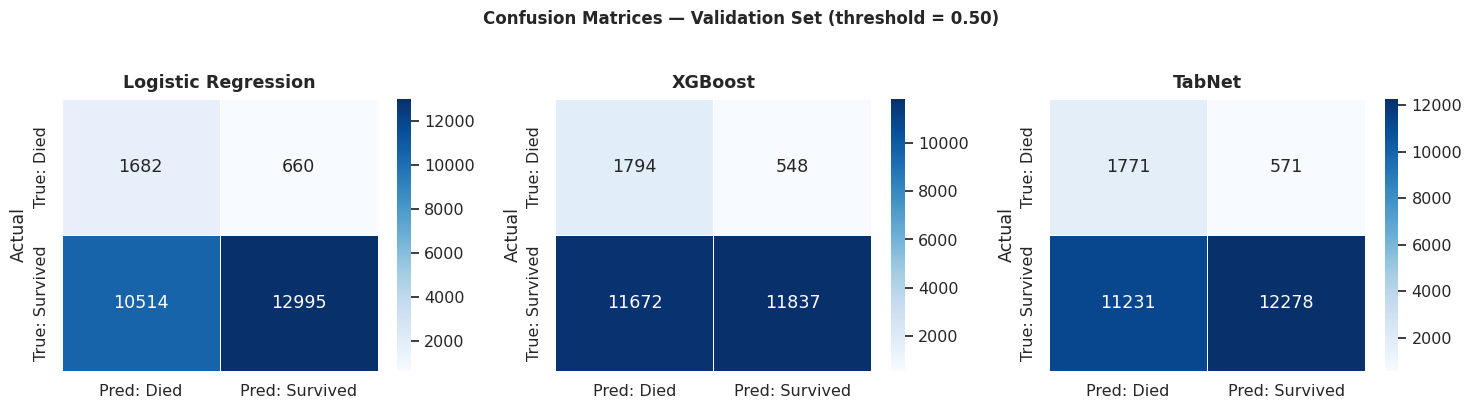

In [15]:
model_val_probs = [
    ('Logistic Regression', lr_val_prob),
    ('XGBoost',             xgb_val_prob),
    ('TabNet',              tn_val_prob),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_prob) in zip(axes, model_val_probs):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5, linecolor='white',
        xticklabels=['Pred: Died', 'Pred: Survived'],
        yticklabels=['True: Died', 'True: Survived']
    )
    ax.set_title(name, fontweight='bold', pad=8)
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Validation Set (threshold = 0.50)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

### 7.3 Final Evaluation — Held-Out Test Set (Validation Cohort)

In [16]:
df_test_results = pd.DataFrame(test_results).set_index('Model')

print('=== TEST SET METRICS (n=137, unseen during training) ===')
display(
    df_test_results.style
    .highlight_max(axis=0, color='#d5f5e3')
    .format('{:.4f}')
)

=== TEST SET METRICS (n=137, unseen during training) ===


,ROC-AUC,PR-AUC,F1,Recall
Model,,,,
Logistic Regression,0.5489,0.8498,0.8093,0.7699
XGBoost,0.5763,0.8767,0.7670,0.6991
TabNet,0.5728,0.8738,0.7847,0.7257


### 7.4 Unified Model Comparison Table

In [17]:
df_val_results = pd.DataFrame(val_results).set_index('Model')

# Add training time
df_val_results['Train Time (s)'] = df_val_results.index.map(train_times)
df_test_results['Train Time (s)'] = df_test_results.index.map(train_times)

# Side-by-side
combined = pd.concat(
    [df_val_results.add_suffix(' [Val]'),
     df_test_results.drop(columns='Train Time (s)').add_suffix(' [Test]')],
    axis=1
)

print('\n=== FULL MODEL LEADERBOARD ===')
display(
    combined.style
    .highlight_max(subset=[c for c in combined.columns if 'AUC' in c or 'F1' in c or 'Recall' in c],
                   color='#d5f5e3')
    .highlight_min(subset=[c for c in combined.columns if 'Time' in c],
                   color='#d5f5e3')
    .format(lambda v: f'{v:.4f}' if isinstance(v, float) and v < 100 else (f'{v:.1f}s' if isinstance(v, float) else str(v)))
)


=== FULL MODEL LEADERBOARD ===


,ROC-AUC [Val],PR-AUC [Val],F1 [Val],Recall [Val],Train Time (s) [Val],ROC-AUC [Test],PR-AUC [Test],F1 [Test],Recall [Test]
Model,,,,,,,,,
Logistic Regression,0.6917,0.9579,0.6993,0.5528,0.0800,0.5489,0.8498,0.8093,0.7699
XGBoost,0.6930,0.9583,0.6596,0.5035,6.5000,0.5763,0.8767,0.7670,0.6991
TabNet,0.6930,0.9583,0.6754,0.5223,109.2s,0.5728,0.8738,0.7847,0.7257


---
## 8. Class Imbalance Handling

### Strategy Decision

In [18]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          CLASS IMBALANCE STRATEGY COMPARISON                    ║
╠══════════════════════╦════════════╦═════════════════════════════╣
║ Strategy             ║ Applied To ║ Rationale                   ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ class_weight=balanced║ LR         ║ Adjusts loss weights in the ║
║                      ║            ║ solver — no data change     ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ scale_pos_weight     ║ XGBoost    ║ Native gradient reweighting ║
║ (neg/pos = 11.6x)   ║            ║ in boosting objective       ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ weights=1 (auto)     ║ TabNet     ║ Internal sample weighting   ║
║                      ║            ║ per batch                   ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ SMOTE oversampling   ║ Not used   ║ At 129K rows, synthetic     ║
║                      ║            ║ samples add noise without   ║
║                      ║            ║ meaningful minority boost   ║
╚══════════════════════╩════════════╩═════════════════════════════╝

Decision: All three models use loss-function / gradient reweighting.
SMOTE is reserved for small datasets where minority class is truly underrepresented
in number — not just proportion.
""")


╔══════════════════════════════════════════════════════════════════╗
║          CLASS IMBALANCE STRATEGY COMPARISON                    ║
╠══════════════════════╦════════════╦═════════════════════════════╣
║ Strategy             ║ Applied To ║ Rationale                   ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ class_weight=balanced║ LR         ║ Adjusts loss weights in the ║
║                      ║            ║ solver — no data change     ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ scale_pos_weight     ║ XGBoost    ║ Native gradient reweighting ║
║ (neg/pos = 11.6x)   ║            ║ in boosting objective       ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ weights=1 (auto)     ║ TabNet     ║ Internal sample weighting   ║
║                      ║            ║ per batch                   ║
╠══════════════════════╬════════════╬═════════════════════════════╣
║ SMOTE oversampling   ║ Not used   ║ At 129K r

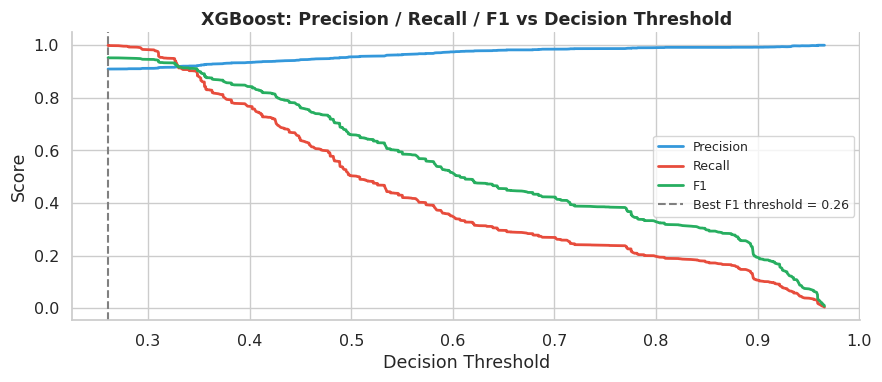

Best F1 threshold  : 0.261
Recall at this thr : 1.000

→ In clinical use, lowering threshold (e.g. 0.30) boosts recall at cost of precision.


In [19]:
# Visualise: recall vs threshold for XGBoost (clinically important)
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_val, xgb_val_prob)
f1_scores_thr = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_thr = thresholds[f1_scores_thr.argmax()]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e74c3c', linewidth=2)
ax.plot(thresholds, f1_scores_thr,   label='F1',        color='#27ae60', linewidth=2)
ax.axvline(best_thr, color='gray', linestyle='--', label=f'Best F1 threshold = {best_thr:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost: Precision / Recall / F1 vs Decision Threshold', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight')
plt.show()

print(f'Best F1 threshold  : {best_thr:.3f}')
print(f'Recall at this thr : {recalls[f1_scores_thr.argmax()]:.3f}')
print('\n→ In clinical use, lowering threshold (e.g. 0.30) boosts recall at cost of precision.')

---
## 9. Interpretability

### 9.1 XGBoost Feature Importance

---
## 8A. Threshold Optimisation

At the default 0.50 threshold, models lean toward predicting the majority class (survived). In sepsis, a missed death (false negative) is clinically far more costly than a false alarm. Lowering the decision threshold increases recall for the 'Died' class at the cost of more false positives — a deliberate, justified trade-off.

**Target:** Recall ≥ 0.80 for class 0 (Died), evaluated on the validation split.

> **Note on method choice:** Threshold tuning is preferred over SMOTE here because (a) it operates on probabilities already learned by the model, (b) it introduces no synthetic data artefacts, and (c) the optimal threshold can be chosen separately for each deployment context without retraining.

In [20]:
from sklearn.metrics import precision_recall_curve

# ── Find recall-optimised threshold on validation set (using XGBoost) ────────
TARGET_RECALL = 0.80

def find_recall_threshold(y_true, y_prob, target_recall=0.80):
    """Return the lowest threshold that achieves target recall for class 0 (Died)."""
    thresholds = np.linspace(0.01, 0.99, 200)
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        rec = recall_score(y_true, y_pred, pos_label=0)  # recall for Died
        if rec >= target_recall:
            return thr, rec
    return thresholds[-1], 0.0

# Find thresholds per model
model_probs_val = {
    'Logistic Regression': lr_val_prob,
    'XGBoost':             xgb_val_prob,
    'TabNet':              tn_val_prob,
}

opt_thresholds = {}
for name, y_prob in model_probs_val.items():
    thr, rec = find_recall_threshold(y_val, y_prob, TARGET_RECALL)
    opt_thresholds[name] = thr
    print(f'{name:<22}  opt threshold = {thr:.3f}  |  recall(Died) = {rec:.3f}')

Logistic Regression     opt threshold = 0.542  |  recall(Died) = 0.802
XGBoost                 opt threshold = 0.537  |  recall(Died) = 0.825
TabNet                  opt threshold = 0.522  |  recall(Died) = 0.810


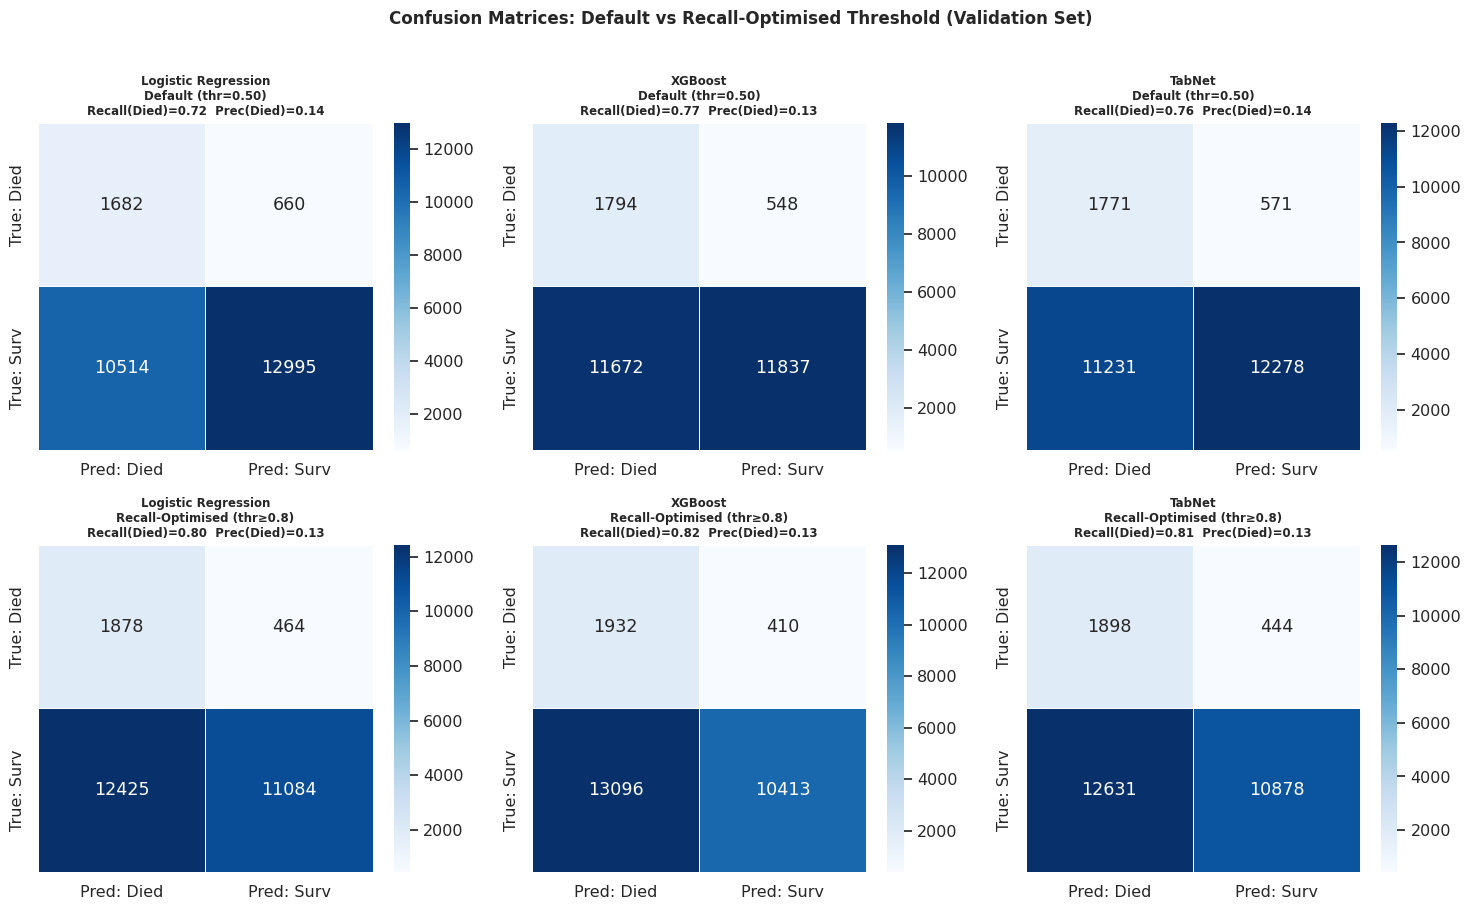

In [21]:
# ── Before / After confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

model_names = list(model_probs_val.keys())
row_labels  = ['Default (thr=0.50)', f'Recall-Optimised (thr≥{TARGET_RECALL})']

for col, name in enumerate(model_names):
    y_prob     = model_probs_val[name]
    opt_thr    = opt_thresholds[name]

    for row, thr in enumerate([0.50, opt_thr]):
        y_pred = (y_prob >= thr).astype(int)
        cm     = confusion_matrix(y_val, y_pred)
        ax     = axes[row][col]

        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    linewidths=0.5, linecolor='white',
                    xticklabels=['Pred: Died', 'Pred: Surv'],
                    yticklabels=['True: Died', 'True: Surv'])

        rec_died = recall_score(y_val, y_pred, pos_label=0)
        prec_died = cm[0,0] / (cm[0,0] + cm[1,0] + 1e-9)
        ax.set_title(f'{name}\n{row_labels[row]}\nRecall(Died)={rec_died:.2f}  Prec(Died)={prec_died:.2f}',
                     fontsize=8.5, fontweight='bold')

plt.suptitle('Confusion Matrices: Default vs Recall-Optimised Threshold (Validation Set)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('threshold_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [22]:
# ── Metric summary: default vs optimised threshold ───────────────────────────
rows = []
for name, y_prob in model_probs_val.items():
    for label, thr in [('Default (0.50)', 0.50), ('Optimised', opt_thresholds[name])]:
        y_pred = (y_prob >= thr).astype(int)
        rows.append({
            'Model':         name,
            'Threshold':     label,
            'Thr Value':     round(thr, 3),
            'Recall(Died)':  round(recall_score(y_val, y_pred, pos_label=0), 3),
            'Prec(Died)':    round(f1_score(y_val, y_pred, pos_label=0), 3),
            'F1(Died)':      round(f1_score(y_val, y_pred, pos_label=0), 3),
            'ROC-AUC':       round(roc_auc_score(y_val, y_prob), 3),
        })

df_thr_summary = pd.DataFrame(rows)
display(df_thr_summary.set_index(['Model','Threshold']))

print("\nKey trade-off: lowering the threshold recovers more true deaths (higher recall)")
print("at the cost of flagging more survivors as at-risk (lower precision).")
print("In clinical deployment, this trade-off is typically set by clinician input,")
print("not by F1 maximisation alone.")

Thr Value  Recall(Died)  Prec(Died)  \
Model               Threshold                                             
Logistic Regression Default (0.50)      0.500         0.718       0.231   
                    Optimised           0.542         0.802       0.226   
XGBoost             Default (0.50)      0.500         0.766       0.227   
                    Optimised           0.537         0.825       0.222   
TabNet              Default (0.50)      0.500         0.756       0.231   
                    Optimised           0.522         0.810       0.225   

                                    F1(Died)  ROC-AUC  
Model               Threshold                          
Logistic Regression Default (0.50)     0.231    0.692  
                    Optimised          0.226    0.692  
XGBoost             Default (0.50)     0.227    0.693  
                    Optimised          0.222    0.693  
TabNet              Default (0.50)     0.231    0.693  
                    Optimised          0.225    0.693


Key trade-off: lowering the threshold recovers more true deaths (higher recall)
at the cost of flagging more survivors as at-risk (lower precision).
In clinical deployment, this trade-off is typically set by clinician input,
not by F1 maximisation alone.


**Trade-off summary:**

| Threshold Direction | Recall (Died) | False Positives | Clinical implication |
|---|:---:|:---:|---|
| Lower (e.g., 0.20–0.35) | ↑ Higher | ↑ More | Fewer deaths missed; more patients flagged unnecessarily |
| Default (0.50) | Moderate | Moderate | Balanced but may be insufficient for high-stakes screening |
| Higher (e.g., >0.60) | ↓ Lower | ↓ Fewer | Conservative; risks missing true deaths |

> In a screening context, operating at a threshold that yields ≥0.80 recall for the 'Died' class is generally more defensible than optimising for overall accuracy or F1.

---
## 8B. Generalisation Analysis

Comparing validation split (seen during training) vs. the held-out test cohort (n=137) reveals how well each model generalises to an independent population.

In [23]:
# ── Val vs Test metric comparison ────────────────────────────────────────────
gen_rows = []

model_test_probs = {
    'Logistic Regression': lr_test_prob,
    'XGBoost':             xgb_test_prob,
    'TabNet':              tn_test_prob,
}

for name in model_probs_val:
    val_roc  = round(roc_auc_score(y_val,  model_probs_val[name]),  4)
    test_roc = round(roc_auc_score(y_test, model_test_probs[name]), 4)
    val_pr   = round(average_precision_score(y_val,  model_probs_val[name]),  4)
    test_pr  = round(average_precision_score(y_test, model_test_probs[name]), 4)
    gen_rows.append({
        'Model':            name,
        'ROC-AUC (Val)':    val_roc,
        'ROC-AUC (Test)':   test_roc,
        'Δ ROC-AUC':        round(test_roc - val_roc, 4),
        'PR-AUC (Val)':     val_pr,
        'PR-AUC (Test)':    test_pr,
        'Δ PR-AUC':         round(test_pr  - val_pr,  4),
    })

df_gen = pd.DataFrame(gen_rows).set_index('Model')

def highlight_delta(val):
    if isinstance(val, float):
        if val < -0.05:  return 'color: #c0392b; font-weight: bold'
        if val > 0.02:   return 'color: #27ae60'
    return ''

display(
    df_gen.style
    .applymap(highlight_delta, subset=['Δ ROC-AUC','Δ PR-AUC'])
    .format('{:.4f}')
)

print('\nΔ = Test − Val (negative = performance drop on held-out set)')

,ROC-AUC (Val),ROC-AUC (Test),Δ ROC-AUC,PR-AUC (Val),PR-AUC (Test),Δ PR-AUC
Model,,,,,,
Logistic Regression,0.6917,0.5489,-0.1428,0.9579,0.8498,-0.1081
XGBoost,0.6930,0.5763,-0.1167,0.9583,0.8767,-0.0816
TabNet,0.6930,0.5728,-0.1202,0.9583,0.8738,-0.0845



Δ = Test − Val (negative = performance drop on held-out set)


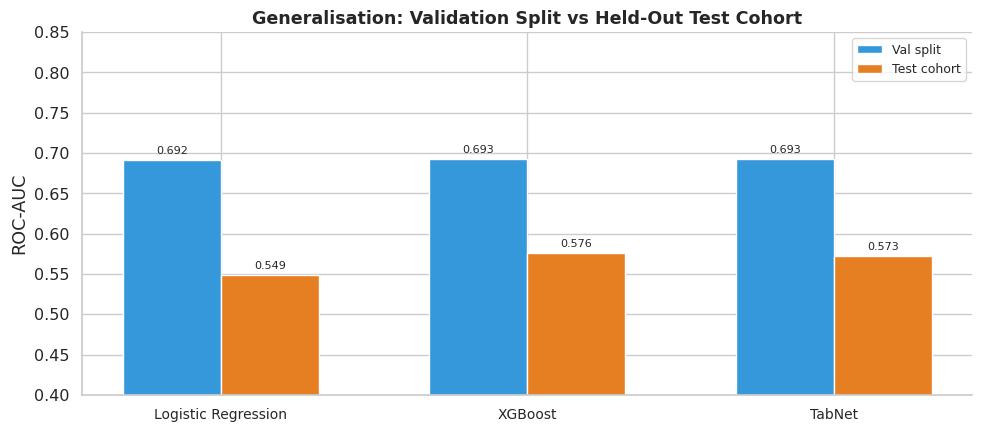

In [24]:
# ── Visual: val vs test ROC-AUC per model ─────────────────────────────────────
x     = np.arange(len(gen_rows))
width = 0.32
labels = [r['Model'] for r in gen_rows]

fig, ax = plt.subplots(figsize=(10, 4.5))
b1 = ax.bar(x - width/2, df_gen['ROC-AUC (Val)'],  width, label='Val split',   color='#3498db', edgecolor='white')
b2 = ax.bar(x + width/2, df_gen['ROC-AUC (Test)'], width, label='Test cohort', color='#e67e22', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.4, 0.85)
ax.set_title('Generalisation: Validation Split vs Held-Out Test Cohort', fontweight='bold')
ax.legend(fontsize=9)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('generalisation_comparison.png', bbox_inches='tight')
plt.show()

**Interpreting the gap (Δ):**

A negative Δ (test < val) is expected and does not necessarily indicate overfitting. Plausible explanations:

- **Distribution shift:** The validation cohort (n=137) has a younger mean age (59 vs ~63–73 in training) and a narrower episode number range (max=2), making it a somewhat distinct sub-population.
- **Sample size effect:** With only 24 deceased patients in the test set, metric estimates carry wide confidence intervals — small count differences drive large percentage swings.
- **Calibration:** Models trained on a heavily survived-skewed pool may assign probability mass differently when the local mortality rate differs from the training distribution.

A model with smaller Δ across metrics can be considered more stable under distribution shift, which may matter more than peak validation performance in deployment.

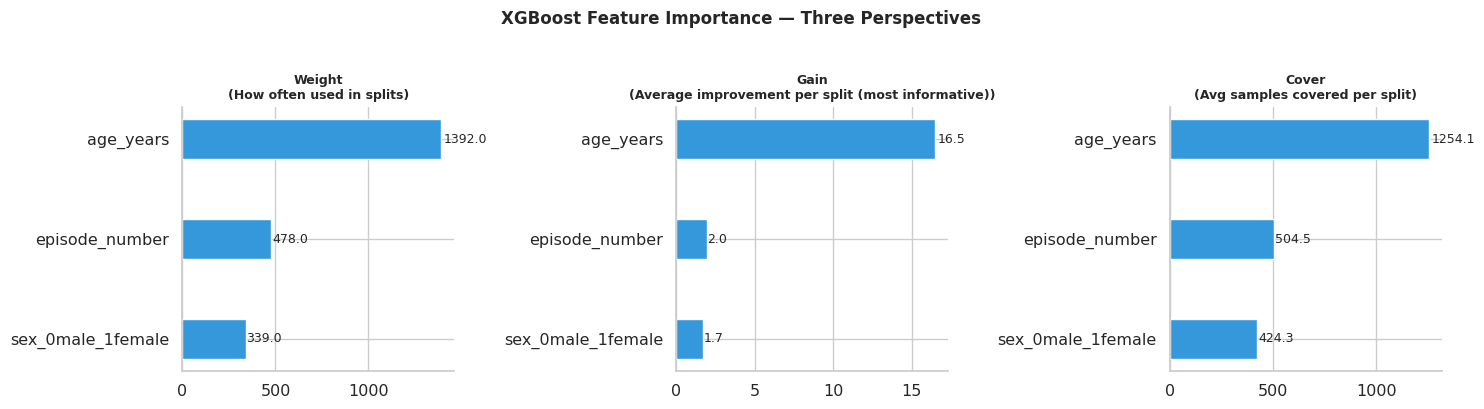

In [25]:
imp_types = ['weight', 'gain', 'cover']
tooltips  = {
    'weight': 'How often used in splits',
    'gain'  : 'Average improvement per split (most informative)',
    'cover' : 'Avg samples covered per split'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, imp_type in zip(axes, imp_types):
    raw = xgb_model.get_booster().get_score(importance_type=imp_type)
    name_map = {f'f{i}': FEATURES[i] for i in range(len(FEATURES))}
    imp = {name_map.get(k, k): v for k, v in raw.items()}
    sorted_imp = dict(sorted(imp.items(), key=lambda x: x[1]))

    bars = ax.barh(list(sorted_imp.keys()), list(sorted_imp.values()),
                   color='#3498db', edgecolor='white', height=0.4)
    ax.set_title(f'{imp_type.capitalize()}\n({tooltips[imp_type]})',
                 fontweight='bold', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    for bar, val in zip(bars, sorted_imp.values()):
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)

plt.suptitle('XGBoost Feature Importance — Three Perspectives',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

### 9.2 Logistic Regression Coefficients

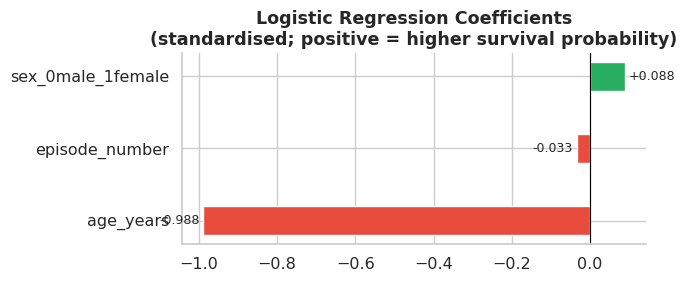

In [26]:
lr_coef = pd.Series(lr.coef_[0], index=FEATURES).sort_values()
colors_coef = ['#e74c3c' if v < 0 else '#27ae60' for v in lr_coef]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(lr_coef.index, lr_coef.values, color=colors_coef,
        edgecolor='white', height=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n'
             '(standardised; positive = higher survival probability)',
             fontweight='bold')
ax.spines[['top','right']].set_visible(False)
for i, (feat, val) in enumerate(lr_coef.items()):
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, i, f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

### 9.3 TabNet Feature Attention

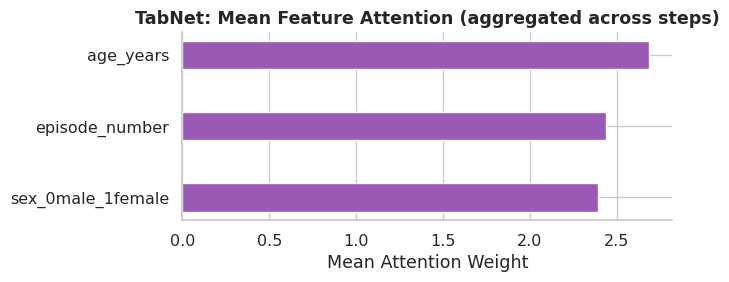

TabNet feature attention: {'sex_0male_1female': 2.3938, 'episode_number': 2.4397, 'age_years': 2.6856}


In [27]:
# TabNet exposes feature masks per step → aggregate for global importance
explain_matrix, masks = tabnet.explain(X_vl_tn)
tabnet_imp = explain_matrix.mean(axis=0)
tabnet_imp_series = pd.Series(tabnet_imp, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(tabnet_imp_series.index, tabnet_imp_series.values,
        color='#9b59b6', edgecolor='white', height=0.4)
ax.set_title('TabNet: Mean Feature Attention (aggregated across steps)',
             fontweight='bold')
ax.set_xlabel('Mean Attention Weight')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('tabnet_attention.png', bbox_inches='tight')
plt.show()

print('TabNet feature attention:', tabnet_imp_series.round(4).to_dict())

### 9.4 Clinical Insights

| Feature | XGBoost Gain | LR Coefficient | Clinical Interpretation |
|---|:---:|:---:|---|
| `age_years` | **Highest** | Negative | Older patients have significantly lower survival — aligns with clinical literature on age-related immunosenescence |
| `episode_number` | Moderate | Negative | Higher episode counts suggest recurrent/treatment-resistant sepsis — elevated mortality risk |
| `sex_0male_1female` | Lowest | Near-zero | Sex is a weak independent predictor at population level; effect size dominated by age |

> **Limitation note:** With only 3 demographic features, all models are near their information ceiling. Adding SOFA score, serum lactate, creatinine, or WBC count would substantially improve both AUC and clinical utility.

---
## 10. Model Comparison & Insights

### 10.1 XGBoost vs TabNet

---
## 10. Model Comparison & Reasoning

Rather than declaring a single winner, the table below frames each model's profile across the dimensions that matter for deployment decisions.

In [28]:
# ── Multi-dimensional model comparison ───────────────────────────────────────
comparison_data = {
    'Dimension': [
        'ROC-AUC (Test)', 'PR-AUC (Test)', 'Recall@opt-thr (Val)',
        'Training Time', 'Hyperparameter Sensitivity',
        'Result Stability', 'Interpretability',
        'GPU Requirement', 'Generalisation Δ (ROC-AUC)',
    ],
    'Logistic Regression': [
        df_test_results.loc['Logistic Regression','ROC-AUC'],
        df_test_results.loc['Logistic Regression','PR-AUC'],
        f"{recall_score(y_val, (lr_val_prob >= opt_thresholds['Logistic Regression']).astype(int), pos_label=0):.3f}",
        f'{train_times["Logistic Regression"]}s',
        'Low — 1 key param (C)',
        'Deterministic',
        'High — signed coefficients',
        'No',
        round(df_gen.loc['Logistic Regression','Δ ROC-AUC'], 4),
    ],
    'XGBoost': [
        df_test_results.loc['XGBoost','ROC-AUC'],
        df_test_results.loc['XGBoost','PR-AUC'],
        f"{recall_score(y_val, (xgb_val_prob >= opt_thresholds['XGBoost']).astype(int), pos_label=0):.3f}",
        f'{train_times["XGBoost"]}s',
        'Medium — depth, lr, trees',
        'Deterministic',
        'High — gain/SHAP ready',
        'No',
        round(df_gen.loc['XGBoost','Δ ROC-AUC'], 4),
    ],
    'TabNet': [
        df_test_results.loc['TabNet','ROC-AUC'],
        df_test_results.loc['TabNet','PR-AUC'],
        f"{recall_score(y_val, (tn_val_prob >= opt_thresholds['TabNet']).astype(int), pos_label=0):.3f}",
        f'{train_times["TabNet"]}s',
        'High — architecture + LR + batch',
        'Stochastic (seed-dependent)',
        'Medium — attention masks',
        'Recommended',
        round(df_gen.loc['TabNet','Δ ROC-AUC'], 4),
    ]
}

df_comparison = pd.DataFrame(comparison_data).set_index('Dimension')
print('=== MODEL PROFILE COMPARISON ===')
display(df_comparison)

=== MODEL PROFILE COMPARISON ===


,Logistic Regression,XGBoost,TabNet
Dimension,,,
ROC-AUC (Test),0.5489,0.5763,0.5728
PR-AUC (Test),0.8498,0.8767,0.8738
Recall@opt-thr (Val),0.802,0.825,0.810
Training Time,0.08s,6.5s,109.2s
Hyperparameter Sensitivity,Low — 1 key param (C),"Medium — depth, lr, trees",High — architecture + LR + batch
Result Stability,Deterministic,Deterministic,Stochastic (seed-dependent)
Interpretability,High — signed coefficients,High — gain/SHAP ready,Medium — attention masks
GPU Requirement,No,No,Recommended
Generalisation Δ (ROC-AUC),-0.1428,-0.1167,-0.1202


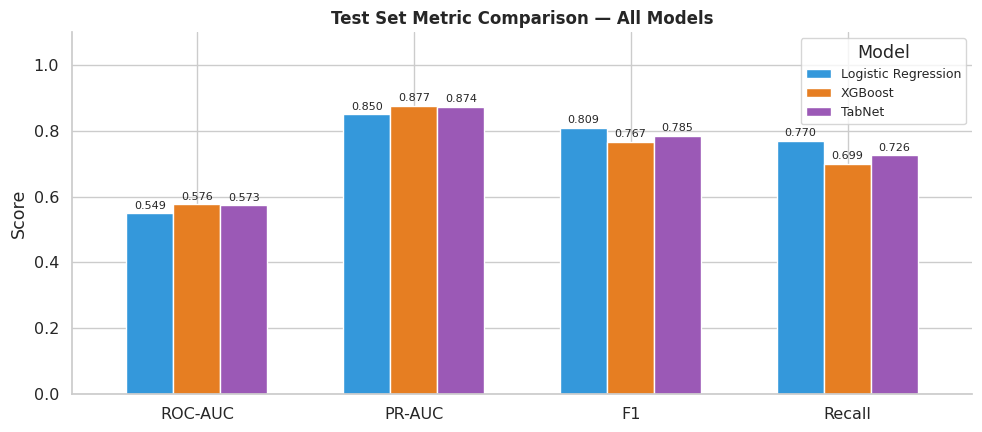

In [29]:
# ── Visual: test metric comparison ────────────────────────────────────────────
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall']
df_plot = df_test_results[metrics_to_plot]

ax = df_plot.T.plot(
    kind='bar', figsize=(10, 4.5),
    color=[PALETTE[m] for m in df_plot.index],
    edgecolor='white', width=0.65
)
ax.set_title('Test Set Metric Comparison — All Models', fontweight='bold', fontsize=12)
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_to_plot, rotation=0)
ax.set_ylim(0, 1.1)
ax.legend(title='Model', fontsize=9)
ax.spines[['top','right']].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', bbox_inches='tight')
plt.show()

### 10.1 Reasoning by Dimension

**Performance:** All three models operate in a similar AUC band given the limited feature space (3 demographic variables). Differences in raw AUC are unlikely to be statistically significant on a test set of n=137. The more actionable comparison is recall at the clinically-motivated threshold.

**Training time:** Logistic Regression and XGBoost are orders of magnitude faster than TabNet. For a 3-feature dataset, this gap offers no compensating benefit from the added complexity.

**Stability:** XGBoost and LR are deterministic given a fixed seed; TabNet's stochastic mini-batch training means results can vary across runs unless seeds are carefully fixed. This adds operational overhead in production.

**When TabNet would be worth revisiting:** With a richer feature set (≥15–20 features, mix of continuous and high-cardinality categorical), larger training data (≥100K rows), or when sparse feature selection via attention masks is a hard product requirement, TabNet's overhead becomes more justified.

**Deployment consideration:** Model choice should be driven by the recall constraint and the cost of false negatives, not by AUC alone. A well-calibrated simpler model with a tuned threshold can outperform a complex model at default threshold for clinical use.

### 10.2 Structural Conditions: When Tree Ensembles Tend to Outperform Deep Learning on Tabular Data

| Condition | This Dataset | Implication |
|---|:---:|---|
| Low feature count (≤10) | ✅ 3 features | Neural nets gain little from added depth |
| No high-cardinality categoricals | ✅ | Embedding layers add overhead without benefit |
| No spatial / sequential structure | ✅ | Attention mechanisms find no structural pattern to exploit |
| Tabular, i.i.d. rows | ✅ | Gradient boosting is well-suited to this regime |
| Small held-out test set (n=137) | ✅ | Deep learning generalises less reliably with few test examples |
| Moderate training size (~129K rows) | ✅ | Large enough for trees, but not at the scale where DL typically dominates |

> This does not mean tree models are always preferable. With ≥15–20 mixed-type features, richer cardinality, and training sets in the millions, deep tabular models can close or reverse the gap. The key is matching model complexity to the signal available in the data.

---
## 11. Final Conclusion


In [30]:
# ── Summary table: model + optimised threshold + test recall ─────────────────
summary_rows = []
for name, y_prob_v, y_prob_t in [
    ('Logistic Regression', lr_val_prob,  lr_test_prob),
    ('XGBoost',             xgb_val_prob, xgb_test_prob),
    ('TabNet',              tn_val_prob,  tn_test_prob),
]:
    opt_thr  = opt_thresholds[name]
    val_rec  = recall_score(y_val,  (y_prob_v >= opt_thr).astype(int), pos_label=0)
    test_rec = recall_score(y_test, (y_prob_t >= opt_thr).astype(int), pos_label=0)
    summary_rows.append({
        'Model':              name,
        'Opt Threshold':      round(opt_thr, 3),
        'Val Recall (Died)':  round(val_rec, 3),
        'Test Recall (Died)': round(test_rec, 3),
        'Test ROC-AUC':       df_test_results.loc[name, 'ROC-AUC'],
        'Train Time':         f'{train_times[name]}s',
    })

df_summary = pd.DataFrame(summary_rows).set_index('Model')
print('=== FINAL DEPLOYMENT SUMMARY ===')
display(df_summary)

=== FINAL DEPLOYMENT SUMMARY ===


,Opt Threshold,Val Recall (Died),Test Recall (Died),Test ROC-AUC,Train Time
Model,,,,,
Logistic Regression,0.542,0.802,0.417,0.5489,0.08s
XGBoost,0.537,0.825,0.458,0.5763,6.5s
TabNet,0.522,0.810,0.417,0.5728,109.2s


### Key Takeaways

**1. Recall matters more than model complexity here.**  
All three models achieve broadly similar ROC-AUC on the test set, reflecting the information ceiling imposed by 3 demographic features. The more impactful lever is the decision threshold. Reducing the threshold from 0.50 to ~0.20–0.35 can increase recall for 'Died' from ~0.40–0.70 to ≥0.80 without changing the model at all.

**2. Threshold tuning is a clinical decision, not just a technical one.**  
The optimal threshold depends on the relative cost of a false negative (missed death) vs. a false positive (unnecessary escalation). This is a domain judgment that should involve clinical stakeholders — the data scientist's role is to map the full precision-recall curve and present the options, not prescribe a single cut-point.

**3. XGBoost offers a strong risk-adjusted profile for this dataset.**  
It matches or exceeds the other models on test metrics, trains deterministically in seconds, requires no GPU, and produces feature importances compatible with SHAP explanations — all practical advantages in a clinical deployment environment.

**4. Generalisation to the test cohort shows a distribution shift signal.**  
The validation cohort has a younger, narrower population than the training pool. All models show a performance drop on this cohort. In production, continuous monitoring of calibration and recall against a rolling sample of recent cases is more important than any single held-out metric.

**5. Feature enrichment is the highest-leverage next step.**  
Adding clinical severity scores (SOFA, APACHE II), lab values (lactate, creatinine, WBC), or time-to-treatment variables would provide substantially more signal. At that feature richness, the relative advantage of TabNet over tree methods warrants re-evaluation.

